In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

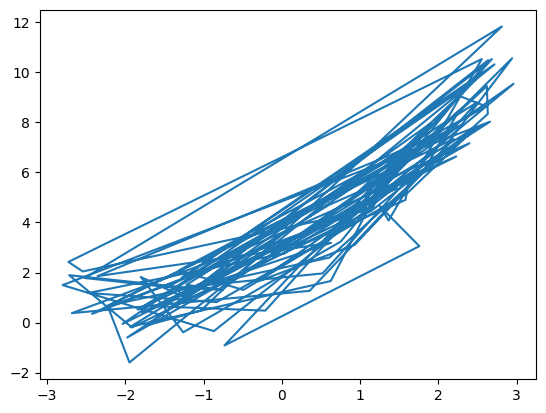

In [7]:
#quadratic equation y = 0.5X^2 + 1.5*X + outliers
X = 6 * np.random.rand(100,1) - 3
y = 0.5*X**2 + 1.5*X + 2 + np.random.randn(100,1)
plt.plot(X,y)

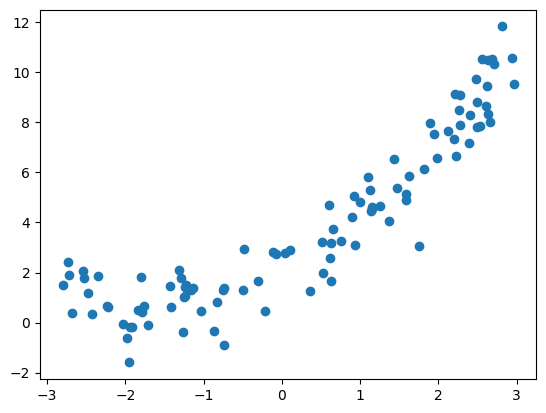

In [8]:
plt.scatter(X,y)

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [12]:
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

In [13]:
regression_1.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
from sklearn.metrics import r2_score
score = r2_score(y_test,regression_1.predict(X_test))
print(score)

0.7739119185691885


Text(0, 0.5, 'y')

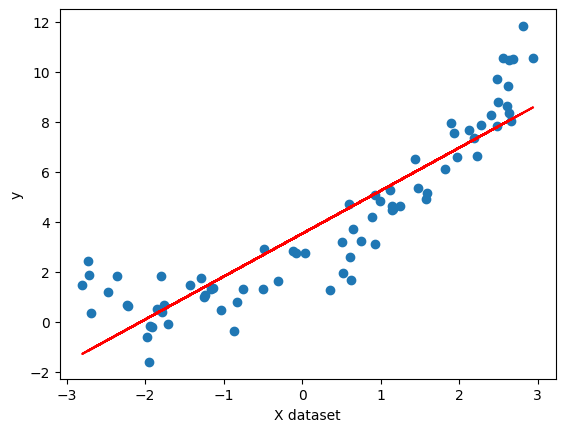

In [15]:
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X dataset")
plt.ylabel("y")

In [16]:
from sklearn.preprocessing import PolynomialFeatures

In [17]:
poly = PolynomialFeatures(degree=2,include_bias=True) # include bias says that there is 1 as coeff of beta0
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [18]:
X_train_poly

array([[ 1.00000000e+00, -1.70929566e+00,  2.92169164e+00],
       [ 1.00000000e+00, -2.72854504e+00,  7.44495805e+00],
       [ 1.00000000e+00, -8.33527820e-01,  6.94768627e-01],
       [ 1.00000000e+00, -2.35535344e+00,  5.54768981e+00],
       [ 1.00000000e+00,  2.40748910e+00,  5.79600376e+00],
       [ 1.00000000e+00, -1.16378564e+00,  1.35439701e+00],
       [ 1.00000000e+00, -7.76652081e-02,  6.03188454e-03],
       [ 1.00000000e+00, -1.13069453e+00,  1.27847013e+00],
       [ 1.00000000e+00, -2.22213270e+00,  4.93787372e+00],
       [ 1.00000000e+00,  2.65922959e+00,  7.07150200e+00],
       [ 1.00000000e+00,  2.68296095e+00,  7.19827948e+00],
       [ 1.00000000e+00,  2.22800866e+00,  4.96402259e+00],
       [ 1.00000000e+00, -4.87510015e-01,  2.37666015e-01],
       [ 1.00000000e+00, -1.93752836e+00,  3.75401616e+00],
       [ 1.00000000e+00,  2.63603972e+00,  6.94870541e+00],
       [ 1.00000000e+00,  2.94206283e+00,  8.65573368e+00],
       [ 1.00000000e+00,  6.00327562e-01

In [19]:
X_test_poly

array([[ 1.        , -1.22104194,  1.49094341],
       [ 1.        ,  2.53254412,  6.41377972],
       [ 1.        ,  2.21271864,  4.89612376],
       [ 1.        , -0.73394734,  0.5386787 ],
       [ 1.        ,  1.75663358,  3.08576155],
       [ 1.        , -2.54506671,  6.47736457],
       [ 1.        ,  2.26797723,  5.14372073],
       [ 1.        , -1.23642152,  1.52873817],
       [ 1.        ,  0.62831538,  0.39478022],
       [ 1.        ,  2.27108933,  5.15784676],
       [ 1.        , -1.26109226,  1.5903537 ],
       [ 1.        , -2.42548662,  5.88298533],
       [ 1.        , -1.31542839,  1.73035184],
       [ 1.        ,  2.39611987,  5.74139042],
       [ 1.        ,  1.62752986,  2.64885344],
       [ 1.        , -0.21178877,  0.04485448],
       [ 1.        ,  2.96033325,  8.76357295],
       [ 1.        , -0.74412842,  0.5537271 ],
       [ 1.        , -2.52296803,  6.36536767],
       [ 1.        ,  1.10057214,  1.21125903],
       [ 1.        , -1.41553524,  2.003

In [21]:
regression_poly = LinearRegression()
regression_poly.fit(X_train_poly,y_train)
y_pred = regression_poly.predict(X_test_poly)
score_poly = r2_score(y_test,y_pred)
print(score_poly)

0.8857851760937144


In [22]:
print(regression_poly.coef_)

[[0.         1.60036338 0.4575873 ]]


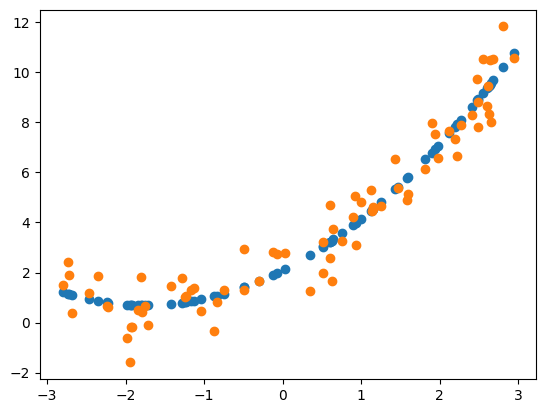

In [27]:
plt.scatter(X_train,regression_poly.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [28]:
from sklearn.pipeline import Pipeline

In [ ]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_feature = PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ("poly_features",poly_feature),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train)
    y_pred_new = poly_regression.predict(X_new)

    #plotting
    plt.plot(X_new, y_pred_new, color='r', label = "degree" + str(degree))
    plt.plot(X_train, y_train, color="b", linewidth=3)
    plt.plot(X_test, y_test, color="g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4,0,10])
    plt.show()

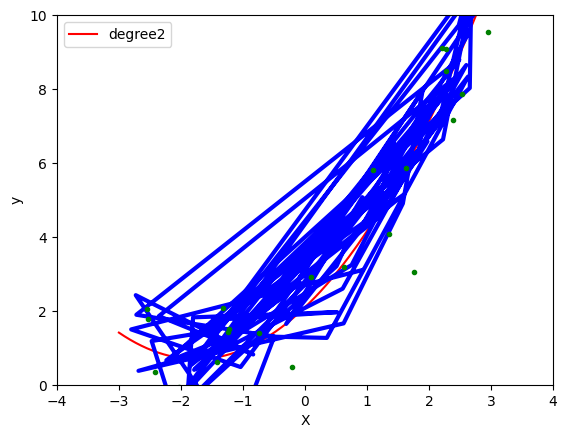

In [32]:
poly_regression(2)